## Importing the Dependencies.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [57]:
df = pd.read_csv("Mall_Customers.csv")
print(df)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [58]:
# Columns Descriptions

#1) CustomerID(Numerical Feature - Integer):- CustomerID is a unique identifier assigned to each customer in the dataset.
# In K-Means clustering, it is typically excluded because it does not contribute to pattern formation i.e. it is not used for Clustering Purpose.

#2) Gender(Categorical Feature):- Gender represents the biological classification of customers(Male/Female).
# It is a categorical variable and usually needs to be encoded (e.g., 0/1) before clustering.

#3) Age(Numerical Feature):- Age indicates the age of each customer in years.
# It is a continuous numerical variable.

#4)Annual Income(k$)(Numerical Feature):- Annual Income represents the yearly income of customers measured in thousands of dollars.
# It is a continuous numerical variable.

#5)Spending Score(1–100)(Numerical Feature):- Spending Score is a metric assigned by the mall based on customer purchasing behavior.
# It ranges from 1 to 100, where higher values indicate higher spending tendencies.
# It is a continuous numerical variable.

## EDA on this Dataset.

In [59]:
# Get the Quick Overview of the Dataset and Understand the structure of the Dataset.

df.shape  # Rows and Columns of the Dataset.
print("Infornmation about the Dataset")
df.info() # Complete Infornmation about the Columns of the Dataset.
df.columns # Infornmation i.e. Names of the Columns about the Dataset.
df.head(5) # Top 5 Rows of the Dataset.
df.tail(5) # Last 5 Rows of the Dataset.
df.dtypes # Getting Data - Types of each Column in the Dataset.
df.count()  # Count Non-Null Values in Each Column.
df.dtypes # Determining the Data - type of Columns in the Dataset.

Infornmation about the Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [60]:
# Checking for the Missing Vaues i.e. find out the Missing Values.

print(df.isnull()) # Null - Values in the form of Boolean Matrix(True - Missing Values , False - Not a mssing Values).
print(df.notnull()) # Opposite of isnull(True - Not a Missing Values , False - Missing Values)
print(df.isnull().sum()) # Count of the Missing Values of each Columns.
# By illustration, it is clear there are no missing values in any column in the Dataset.

     CustomerID  Gender    Age  Annual Income (k$)  Spending Score (1-100)
0         False   False  False               False                   False
1         False   False  False               False                   False
2         False   False  False               False                   False
3         False   False  False               False                   False
4         False   False  False               False                   False
..          ...     ...    ...                 ...                     ...
195       False   False  False               False                   False
196       False   False  False               False                   False
197       False   False  False               False                   False
198       False   False  False               False                   False
199       False   False  False               False                   False

[200 rows x 5 columns]
     CustomerID  Gender   Age  Annual Income (k$)  Spending Score (1-100)
0 

In [61]:
# Handling Duplicates in the Dataset.

print(df.duplicated())  # Reurns a Boolean series i.e. True denotes Duplicate Value and False denotes Not a Duplicate Value.
print(df.duplicated().sum()) # Sum of the Duplicate Values of the rows in the dataset(415 here).
df = df.drop_duplicates() #Dropping the Duplicate Rows in the Dataset.
print(df)

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool
0
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   3

## Univariate Analysis

## Gender Column.

In [62]:
print(df['Gender'].value_counts())

Gender
Female    112
Male       88
Name: count, dtype: int64


## Countplot

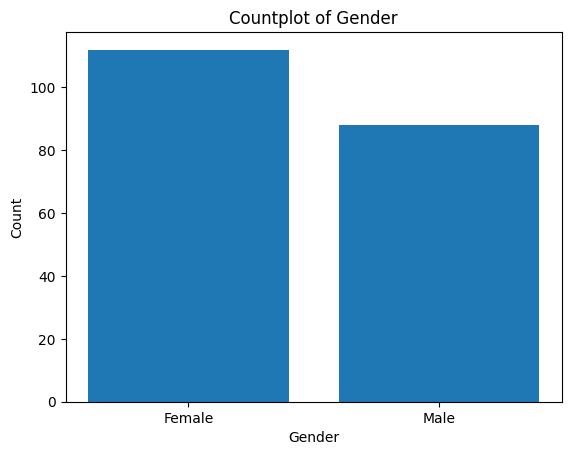

In [63]:
plt.figure()
gender_counts = df['Gender'].value_counts()
plt.bar(gender_counts.index, gender_counts.values)

plt.title("Countplot of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

## Annual Income (k$) Column


In [64]:
print(df['Annual Income (k$)'].describe())

count    200.000000
mean      60.560000
std       26.264721
min       15.000000
25%       41.500000
50%       61.500000
75%       78.000000
max      137.000000
Name: Annual Income (k$), dtype: float64


## Histogram

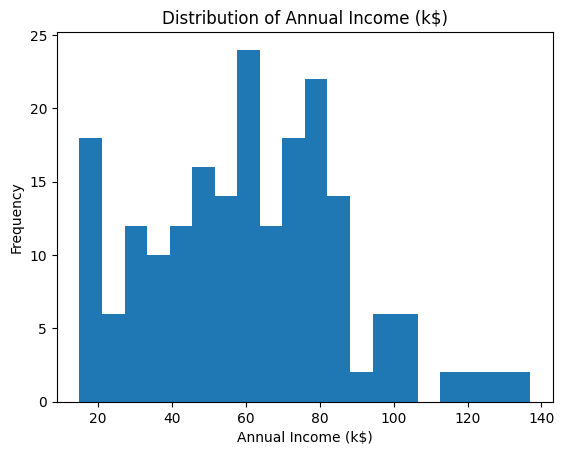

In [65]:
plt.figure()
plt.hist(df['Annual Income (k$)'], bins=20)
plt.title("Distribution of Annual Income (k$)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")
plt.show()

## Boxplot

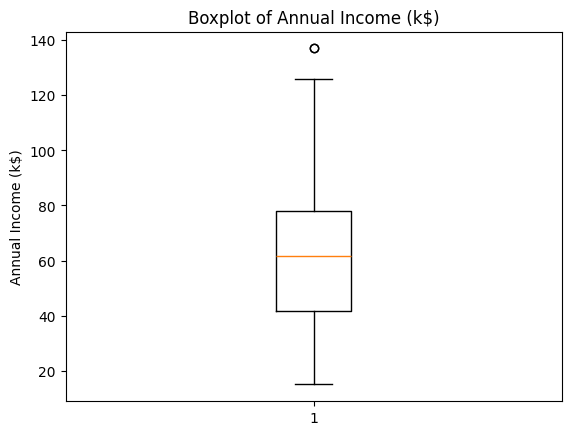

In [66]:
plt.figure()
plt.boxplot(df['Annual Income (k$)'])
plt.title("Boxplot of Annual Income (k$)")
plt.ylabel("Annual Income (k$)")
plt.show()

## Bivariate Analysis

## Annual Income vs Spending Score

## Scatterplot

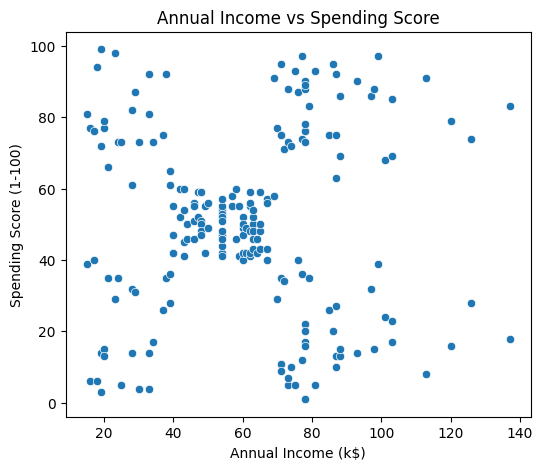

In [67]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='Annual Income (k$)', 
                y='Spending Score (1-100)', 
                data=df)

plt.title("Annual Income vs Spending Score")
plt.show()

## Age vs Spending Score

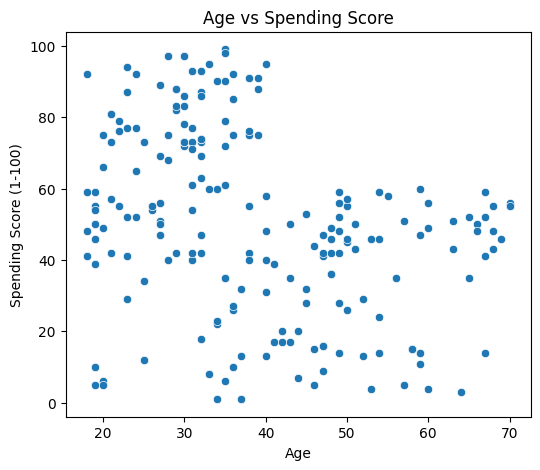

In [68]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='Age', 
                y='Spending Score (1-100)', 
                data=df)

plt.title("Age vs Spending Score")
plt.show()

## Feature Engineering

## Handling Outliers

In [69]:
def cap_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return np.clip(column, lower_bound, upper_bound)

df['Annual Income (k$)'] = cap_outliers(df['Annual Income (k$)'])
df['Spending Score (1-100)'] = cap_outliers(df['Spending Score (1-100)'])
df['Age'] = cap_outliers(df['Age'])


## Encoding

## Encode Categorical Variable(Gender)

In [70]:
# Clean the column (removes spaces & standardizes text)
df['Gender'] = df['Gender'].astype(str).str.strip().str.capitalize()

# Encode Gender: Male = 0, Female = 1
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Verify encoding
print(df['Gender'].unique())
print(df.head())

[0 1]
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1       0   19                15.0                      39
1           2       0   21                15.0                      81
2           3       1   20                16.0                       6
3           4       1   23                16.0                      77
4           5       1   31                17.0                      40


## Feature Selection for Clustering

In [71]:
# For customer segmentation, most impactful features:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

## Feature Scaling

In [74]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature Engineering Completed.")
print("Final shape for clustering:", X_scaled.shape)

Feature Engineering Completed.
Final shape for clustering: (200, 2)


## Choosing the number of Clusters

## Elbow Method(Find Optimal K)

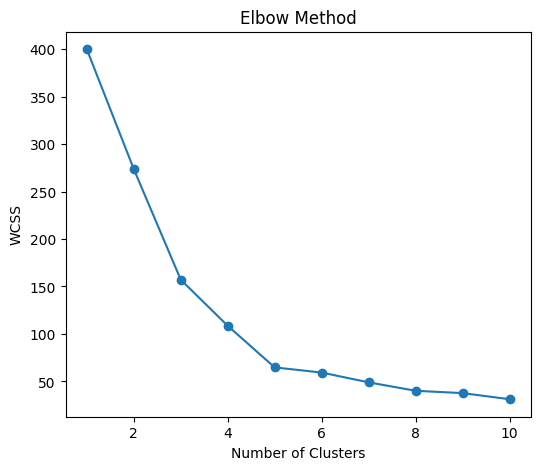

In [75]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## Apply K-Means(K = 5)

In [76]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = y_kmeans

## Visualize the Clusters

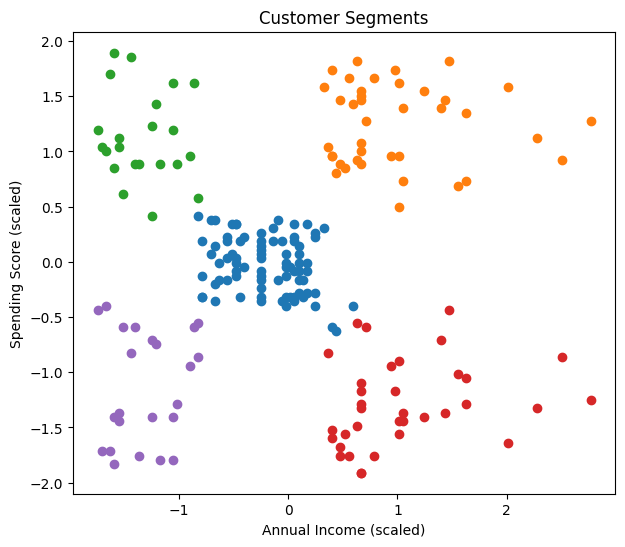

In [77]:
plt.figure(figsize=(7,6))

plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1])
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1])
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1])
plt.scatter(X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1])
plt.scatter(X_scaled[y_kmeans == 4, 0], X_scaled[y_kmeans == 4, 1])

plt.title("Customer Segments")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()